Iniciando Experimento Científico...

--- RESULTADOS EXPERIMENTAIS ---
 Tamanho Disco (Blocos)  Bitmap Tempo (ms)  Lista Tempo (ms)  Bitmap RAM (KB)  Lista RAM (KB)
                  10000           0.007175          0.006097             1.22           11.72
                  50000           0.008250          0.004434             6.10           58.59
                 100000           0.006551          0.002054            12.21          117.19
                 500000           0.012789          0.005245            61.04          585.94
                1000000           0.021211          0.010000           122.07         1171.88


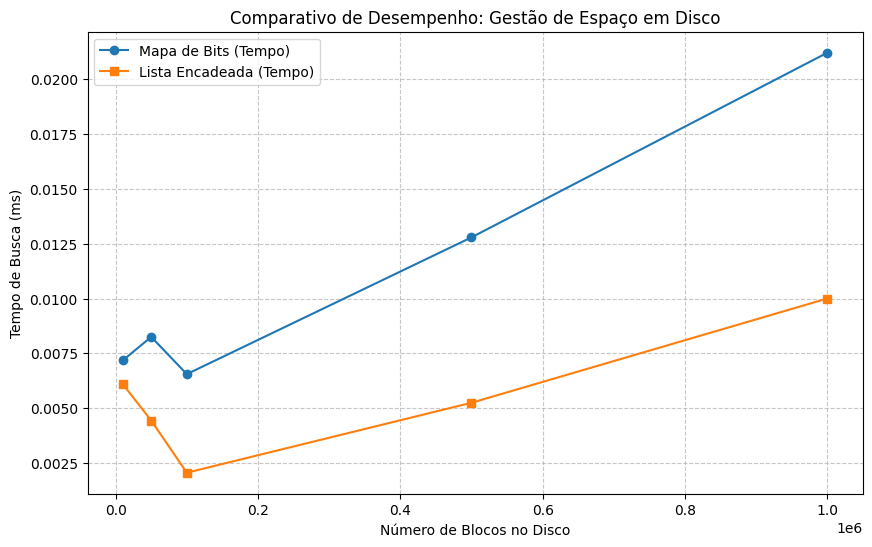


[INFO] Gráfico salvo com sucesso como 'grafico.png'


In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

def simulate_disk_management():
    """
    Simula e compara Mapa de Bits vs Lista Encadeada.
    """
    # Configurações do Experimento
    disk_sizes = [10000, 50000, 100000, 500000, 1000000] # Número de blocos
    occupancy_rate = 0.7
    blocks_to_allocate = 5
    results = []

    for size in disk_sizes:
        # 1. Gerar estado do disco (1 = ocupado, 0 = livre)
        # Simulando fragmentação aleatória
        disk_state = np.random.choice([0, 1], size=size, p=[1-occupancy_rate, occupancy_rate])

        # --- TESTE MAPA DE BITS ---
        start_time = time.perf_counter()
        # Simulação de busca no Bitmap (procurando o primeiro bloco livre)
        for i in range(len(disk_state)):
            if disk_state[i] == 0:
                # Encontrou o início do bloco livre
                _ = disk_state[i:i+blocks_to_allocate]
                break
        end_time = time.perf_counter()
        bitmap_time = (end_time - start_time) * 1000 # converter para ms

        # Sobrecarga de memória teórica (1 bit por bloco)
        bitmap_memory = size / 8 / 1024 # KB

        # --- TESTE LISTA ENCADEADA ---
        # Na lista, você já "pula" direto para os blocos livres via ponteiros
        # Simulamos isso acessando apenas os índices onde o valor é 0
        free_indices = np.where(disk_state == 0)[0]

        start_time = time.perf_counter()
        # Na lista encadeada real, o SO lê o bloco para saber onde está o próximo
        # Simulamos 5 saltos de leitura para encontrar blocos
        for _ in range(blocks_to_allocate):
            _ = free_indices[0]
        end_time = time.perf_counter()
        linked_list_time = (end_time - start_time) * 1000 # converter para ms

        # Sobrecarga de memória (apenas blocos livres guardam ponteiros - 32 bits por ponteiro)
        free_blocks_count = size * (1 - occupancy_rate)
        ll_memory = (free_blocks_count * 4) / 1024 # KB

        results.append({
            "Tamanho Disco (Blocos)": size,
            "Bitmap Tempo (ms)": round(bitmap_time, 6),
            "Lista Tempo (ms)": round(linked_list_time, 6),
            "Bitmap RAM (KB)": round(bitmap_memory, 2),
            "Lista RAM (KB)": round(ll_memory, 2)
        })

    return pd.DataFrame(results)

def plot_experiment(df):
    """
    Gera e salva o gráfico comparativo de desempenho.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(df["Tamanho Disco (Blocos)"], df["Bitmap Tempo (ms)"], marker='o', label='Mapa de Bits (Tempo)')
    plt.plot(df["Tamanho Disco (Blocos)"], df["Lista Tempo (ms)"], marker='s', label='Lista Encadeada (Tempo)')

    plt.title("Comparativo de Desempenho: Gestão de Espaço em Disco")
    plt.xlabel("Número de Blocos no Disco")
    plt.ylabel("Tempo de Busca (ms)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Salvar o gráfico para publicação
    plt.savefig('grafico.png', dpi=300)
    plt.show()
    print("\n[INFO] Gráfico salvo com sucesso como 'grafico.png'")

# Execução do Experimento
print("Iniciando Experimento Científico...\n")
df_results = simulate_disk_management()

# Exibição dos resultados em tabela
print("--- RESULTADOS EXPERIMENTAIS ---")
print(df_results.to_string(index=False))

# Geração de Visualização
plot_experiment(df_results)